<div style="background-color: #f3e5f5; padding: 25px; border-radius: 15px; border: 2px solid #7b1fa2; box-shadow: 2px 2px 8px rgba(0,0,0,0.1); text-align: center; direction: rtl; font-family: 'Vazir', Tahoma, sans-serif;">
<div style="color: #4a148c; font-size: 2em; font-weight: bold; margin-bottom: 8px;">کتاب درک شهودی یادگیری ماشین</div>
<hr style="border: none; border-top: 2px solid #7b1fa2; width: 50%; margin: 12px auto;">
<h2 style="color: #4a148c; margin: 0; font-size: 1.5em; border-bottom: none;">فصل شانزدهم: الگوریتم‌های یادگیری بدون ناظر  (خوشه‌بندی)</h2>
</div>

<div dir="rtl" align="right">

## گام ۱ آماده‌سازی و فاصله
برای اینکه وابسته به وضعیت نوت‌بوک فصل ۵ نباشیم، داده را دوباره می‌خوانیم. فقط سه ستون لازم بارگذاری می‌شود. سال ثابت ۲۰۲۱ انتخاب آموزشی است و در همه ماه‌های آن رکورد داریم؛ این موضوع کامل بودن منبع را ثابت نمی‌کند.

</div>

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

file_path = Path("Crime_data from 2001 to present.csv")
if not file_path.exists():
    file_path = Path("..") / file_path
cols = ["Date", "Community Area", "Primary Type"]
df = pd.read_csv(file_path, usecols=cols, dtype="string")
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y %H:%M")
work = df.loc[df["Date"].dt.year.eq(2021)].copy()
work["Community Area"] = pd.to_numeric(work["Community Area"])
print("Records:", len(work), "Months:", work["Date"].dt.month.nunique())

Records: 201221 Months: 12


In [2]:
from sklearn.preprocessing import StandardScaler

features = ["THEFT", "BATTERY", "CRIMINAL DAMAGE", "ASSAULT",
            "MOTOR VEHICLE THEFT"]
counts = pd.crosstab(work["Community Area"], work["Primary Type"])
records_per_area = counts.sum(axis=1)
profiles = counts[features].div(records_per_area, axis=0) * 100
scaler = StandardScaler()
X = scaler.fit_transform(profiles)
print("Areas and features:", X.shape)
display(profiles.head(3).round(2))

Areas and features: (77, 5)


Primary Type,THEFT,BATTERY,CRIMINAL DAMAGE,ASSAULT,MOTOR VEHICLE THEFT
Community Area,,,,,
1,26.09,20.48,12.73,8.39,3.91
2,24.56,18.18,14.00,7.24,3.98
3,25.01,21.26,9.57,10.49,3.03


<div dir="rtl" align="right">

برای هر منطقه، درصد رکوردهای مربوط به هر یک از پنج نوع جرم را محاسبه می‌کنیم؛ مخرجِ هر درصد، تمام رکوردهای همان منطقه است. شمارهٔ منطقه و تعداد کل گزارش‌های آن، ویژگیِ خوشه‌بندی نیستند. پنج ستون درصد را استاندارد می‌کنیم تا اختلاف مقیاس آن‌ها بر فاصله غالب نشود. در این فایل، تعداد گزارش‌های مناطق بین ۲۳۴ و ۱۱۳۲۰ است؛ پس درصدهای به‌دست‌آمده لزوماً دقت آماری یکسانی ندارند.

</div>

In [3]:
from scipy.spatial.distance import euclidean, cityblock, cosine

a, b = X[0], X[1]
distances = pd.Series({
    "Euclidean on scaled features": euclidean(a, b),
    "Manhattan on scaled features": cityblock(a, b),
    "Cosine on percentage profiles": cosine(profiles.iloc[0], profiles.iloc[1])
}, name="Distance")
print("Area IDs:", profiles.index[0], profiles.index[1])
display(distances.round(4).to_frame())

Area IDs: 1 2


,Distance
Euclidean on scaled features,1.0226
Manhattan on scaled features,1.9860
Cosine on percentage profiles,0.0024


<div dir="rtl" align="right">

اقلیدسی و منهتن روی ویژگی‌های استانداردشده محاسبه شدند. کسینوسی را روی بردار سهم‌های بدون مرکزدهی گرفته‌ایم تا معنای الگوی نسبی حفظ شود. عدد این سه معیار را مستقیماً با هم مقایسه نمی‌کنیم؛ واحد و تعریف آن‌ها متفاوت است.

</div>

<div dir="rtl" align="right">

## گام ۲ انتخاب K و اجرای K-Means

تعداد خوشه را از ۲ تا ۶ تغییر می‌دهیم و برای هر حالت، اینرسی و سیلوئت را حساب می‌کنیم. اینرسی مجموعِ مربع فاصلهٔ هر نقطه تا مرکز خوشهٔ خودش است. سیلوئت فشردگی درون خوشه و جدایی از خوشه‌های دیگر را می‌سنجد و برای یک خوشه قابل محاسبه نیست. بذر تصادفی و تعداد شروع‌های الگوریتم مشخص‌اند تا اجرا تکرارپذیر باشد.

</div>

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

models, rows = {}, []
for k in range(2, 7):
    model = KMeans(n_clusters=k, n_init=20, random_state=42).fit(X)
    models[k] = model
    rows.append({"K": k, "Inertia": model.inertia_,
                 "Silhouette": silhouette_score(X, model.labels_)})
k_scores = pd.DataFrame(rows).set_index("K")
display(k_scores.round(4))

,Inertia,Silhouette
K,,
2,228.4297,0.3477
3,174.2461,0.3339
4,139.5157,0.3492
5,123.7789,0.2330
6,110.2024,0.2309


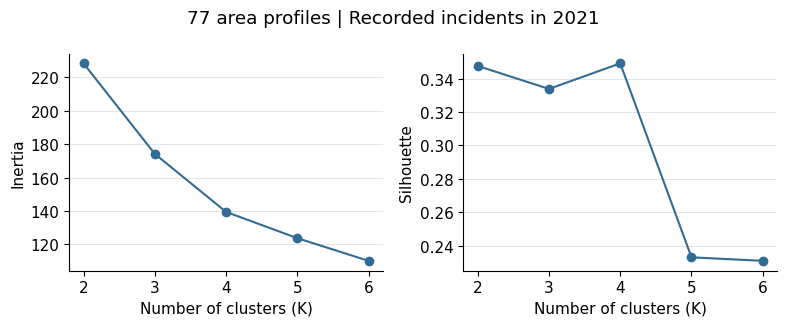

In [5]:
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (8, 3.5), "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
fig, axes = plt.subplots(1, 2, figsize=(8, 3.3))
for ax, metric in zip(axes, ["Inertia", "Silhouette"]):
    ax.plot(k_scores.index, k_scores[metric], "o-", color="#326B93")
    ax.set(xlabel="Number of clusters (K)", ylabel=metric,
           xticks=k_scores.index)
    ax.grid(axis="y", color="#E2E5E9", linewidth=0.7)
fig.suptitle("77 area profiles | Recorded incidents in 2021")
fig.tight_layout()
plt.show()

<div dir="rtl" align="right">

در این اجرا، K=۴ با سیلوئت حدود ۰٫۳۴۹۲ بیشترین مقدار جدول را دارد؛ K=۲ با ۰٫۳۴۷۷ بسیار نزدیک است. پس برتری چهار خوشه قاطع نیست. برای ادامه مثال، بیشترین مقدار جدول را انتخاب می‌کنیم؛ نتیجه را «تعداد واقعی یا قطعی خوشه‌ها» نمی‌نامیم. کم شدن اینرسی با افزایش K به‌تنهایی دلیل بهبود مدل نیست.

</div>

In [6]:
best_k = int(k_scores["Silhouette"].idxmax())
kmeans = models[best_k]
k_labels = kmeans.labels_
cluster_sizes = pd.Series(k_labels).value_counts().sort_index()
cluster_means = profiles.assign(Cluster=k_labels).groupby("Cluster").mean()
print("Selected K:", best_k)
display(cluster_sizes.rename("Areas").to_frame())
display(cluster_means.round(1))

Selected K: 4


,Areas
0,35
1,9
2,27
3,6


Primary Type,THEFT,BATTERY,CRIMINAL DAMAGE,ASSAULT,MOTOR VEHICLE THEFT
Cluster,,,,,
0,14.0,22.1,13.9,11.8,5.3
1,33.7,14.1,8.7,7.0,5.8
2,21.7,17.3,12.1,8.4,4.2
3,19.2,18.6,10.8,10.1,8.5


<div dir="rtl" align="right">

خوشه‌های صفر تا سه به‌ترتیب ۳۵، ۹، ۲۷ و ۶ منطقه دارند. برای هر خوشه، میانگین درصدِ هر نوع جرم را در مناطق عضو محاسبه می‌کنیم. هر منطقه در این میانگین وزن یکسان دارد، حتی اگر تعداد گزارش‌هایش متفاوت باشد. شمارهٔ خوشه فقط یک شناسه است و رتبهٔ منطقه‌ها را نشان نمی‌دهد.

</div>

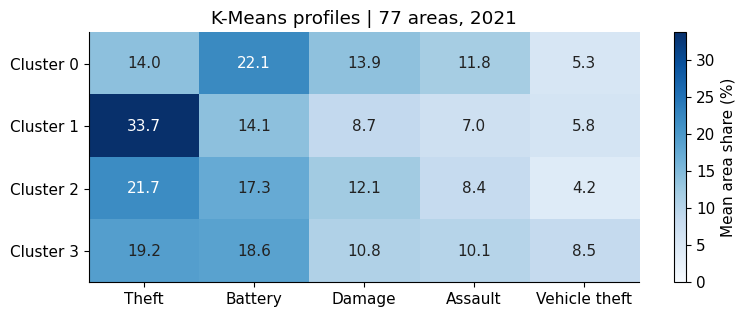

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.3))
short_names = ["Theft", "Battery", "Damage", "Assault", "Vehicle theft"]
image = ax.imshow(cluster_means, cmap="Blues", vmin=0,
                  vmax=float(cluster_means.to_numpy().max()), aspect="auto")
ax.set(xticks=range(5), xticklabels=short_names,
       yticks=range(best_k), yticklabels=[f"Cluster {i}" for i in range(best_k)])
for i in range(best_k):
    for j in range(5):
        value = cluster_means.iloc[i, j]
        color = "white" if value > cluster_means.to_numpy().max() * 0.6 else "#222222"
        ax.text(j, i, f"{value:.1f}", ha="center", va="center", color=color)
fig.colorbar(image, ax=ax, label="Mean area share (%)")
ax.set_title("K-Means profiles | 77 areas, 2021")
fig.tight_layout()
plt.show()

<div dir="rtl" align="right">

### شاخص دان و کنترل پایداری اولیه
در نسخه زیر، صورت شاخص دان کمترین فاصله بین دو عضو از دو خوشه متفاوت و مخرج آن بزرگ‌ترین قطر یک خوشه است. این تعریف را صریح نگه می‌داریم چون گونه‌های دیگری هم وجود دارد. همچنین توافق برچسب‌ها را برای چند بذر اولیه با ARI می‌سنجیم؛ این کنترل فقط حساسیت به مقداردهی اولیه را بررسی می‌کند و جای آزمون پایداری در زمان یا بازنمونه‌گیری را نمی‌گیرد.

</div>

In [8]:
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import adjusted_rand_score

D = squareform(pdist(X))
groups = [np.flatnonzero(k_labels == c) for c in np.unique(k_labels)]
diameter = max(D[np.ix_(g, g)].max() for g in groups)
separation = min(D[np.ix_(a, b)].min() for i, a in enumerate(groups)
                 for b in groups[i + 1:])
dunn = separation / diameter
stability = []
for seed in [7, 21, 84]:
    labels = KMeans(n_clusters=best_k, n_init=20, random_state=seed).fit_predict(X)
    stability.append(adjusted_rand_score(k_labels, labels))
print("Dunn index:", round(dunn, 4))
print("ARI across seeds:", np.round(stability, 3))

Dunn index: 0.2133
ARI across seeds: [1. 1. 1.]


<div dir="rtl" align="right">

K-Means++ در اجرای بالا روش مقداردهی اولیه پیش‌فرض است، نه روشی برای کشف خودکار K. K-Median و K-Medoids در متن به‌عنوان تغییر روش انتخاب مرکز معرفی شده‌اند؛ برای کوتاه ماندن مسیر اصلی، اینجا پیاده‌سازی جدا ندارند.

</div>

<div dir="rtl" align="right">

## گام ۳ خوشه‌بندی سلسله‌مراتبی
با همان X، روش Ward را اجرا می‌کنیم. Ward با فاصله اقلیدسی تعریف می‌شود. درخت کامل ساخته می‌شود و سپس برای مقایسه آموزشی، آن را به همان چهار خوشه می‌بریم؛ این انتخاب به معنی توافق دو الگوریتم نیست.

</div>

In [9]:
from scipy.cluster.hierarchy import linkage, cut_tree, dendrogram

Z = linkage(X, method="ward", metric="euclidean")
h_labels = cut_tree(Z, n_clusters=best_k).ravel()
print("Ward silhouette:", round(silhouette_score(X, h_labels), 4))
display(pd.Series(h_labels).value_counts().sort_index().rename("Areas").to_frame())

Ward silhouette: 0.3461


,Areas
0,31
1,8
2,33
3,5


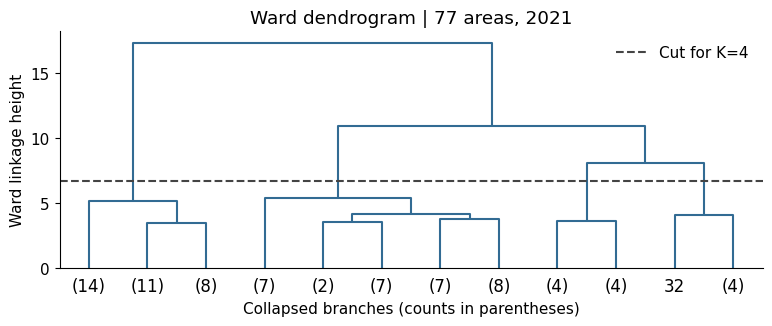

In [10]:
cut_height = (Z[-best_k, 2] + Z[-best_k + 1, 2]) / 2
fig, ax = plt.subplots(figsize=(8, 3.4))
dendrogram(Z, truncate_mode="lastp", p=12, show_leaf_counts=True,
           color_threshold=0, above_threshold_color="#326B93", ax=ax)
ax.axhline(cut_height, color="#444444", linestyle="--", label="Cut for K=4")
ax.set(xlabel="Collapsed branches (counts in parentheses)",
       ylabel="Ward linkage height", title="Ward dendrogram | 77 areas, 2021")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

<div dir="rtl" align="right">

اندازه خوشه‌های Ward برابر ۳۱، ۸، ۳۳ و ۵ منطقه و سیلوئت حدود ۰٫۳۴۶۱ است. نمودار برای خوانایی به ۱۲ شاخه پایانی خلاصه شده است؛ اعداد داخل پرانتز، تعداد مشاهدات تجمیع‌شده‌اند و همه برگ‌ها شماره منطقه نیستند. ارتفاع برش از درخت کامل محاسبه شده است.

</div>

In [11]:
from scipy.cluster.hierarchy import cophenet
from sklearn.metrics import calinski_harabasz_score

linkage_rows = []
for method in ["single", "complete", "average", "ward"]:
    tree = linkage(X, method=method)
    labels = cut_tree(tree, n_clusters=best_k).ravel()
    linkage_rows.append({"Linkage": method,
        "Silhouette": silhouette_score(X, labels),
        "Calinski-Harabasz": calinski_harabasz_score(X, labels),
        "Cophenetic": cophenet(tree, pdist(X))[0]})
linkage_scores = pd.DataFrame(linkage_rows).set_index("Linkage")
display(linkage_scores.round(4))

,Silhouette,Calinski-Harabasz,Cophenetic
Linkage,,,
single,0.0999,3.5141,0.6269
complete,0.3388,39.6941,0.6051
average,0.2090,13.7903,0.7642
ward,0.3461,41.1569,0.5591


<div dir="rtl" align="right">

کوفنتیک کیفیت بازنمایی فاصله‌ها در کل درخت را بررسی می‌کند؛ کالینسکی–هاراباز و سیلوئت درباره برش نهایی‌اند. لازم نیست یک نوع پیوند در همه معیارها بهترین باشد. نتیجه single در این داده شامل یک خوشه بسیار بزرگ و چند تک‌عضوی است؛ فقط به یک امتیاز نگاه نمی‌کنیم.

</div>

<div dir="rtl" align="right">

## گام ۴ DBSCAN و حساسیت به پارامتر

در این مثال، دو منطقه وقتی نزدیک‌اند که پنج درصدِ مربوط به انواع جرم در آن‌ها شبیه باشد؛ منظور نزدیکی روی نقشه نیست. چند مقدار eps را با min_samples برابر پنج امتحان می‌کنیم. برای هسته‌ای بودن یک نقطه، دست‌کم پنج نقطه، با احتساب خودش، باید در شعاع eps آن قرار داشته باشند. مقدار eps در این مثال واحد متر ندارد.

</div>

In [12]:
from sklearn.cluster import DBSCAN

eps_rows = []
for eps in [0.6, 0.8, 1.0, 1.2, 1.4, 1.6]:
    labels = DBSCAN(eps=eps, min_samples=5).fit_predict(X)
    eps_rows.append({"eps": eps, "Clusters": len(set(labels) - {-1}),
                     "Noise areas": int((labels == -1).sum())})
eps_scores = pd.DataFrame(eps_rows)
display(eps_scores)

,eps,Clusters,Noise areas
0,0.6,0,77
1,0.8,2,54
2,1.0,2,41
3,1.2,1,22
4,1.4,1,13
5,1.6,2,5


<div dir="rtl" align="right">

در eps=۰٫۶ همه ۷۷ منطقه نویز می‌شوند؛ در eps=۱٫۲ یک خوشه و ۲۲ نویز داریم. این تغییرها نشان می‌دهند تعداد خوشه خروجی به تنظیمات حساس است. eps=۱ را صرفاً برای نمایش دو خوشه همراه نویز انتخاب می‌کنیم؛ این انتخاب بهینه‌سازی معتبر پارامتر نیست.

</div>

In [13]:
dbscan = DBSCAN(eps=1.0, min_samples=5).fit(X)
db_labels = dbscan.labels_
core = np.zeros(len(X), dtype=bool)
core[dbscan.core_sample_indices_] = True
roles = np.where(db_labels == -1, "Noise", np.where(core, "Core", "Border"))
print("DBSCAN cluster sizes:")
display(pd.Series(db_labels).value_counts().sort_index().rename("Areas").to_frame())
display(pd.Series(roles).value_counts().rename("Areas").to_frame())

DBSCAN cluster sizes:


,Areas
-1,41
0,5
1,31


,Areas
Noise,41
Core,25
Border,11


<div dir="rtl" align="right">

خروجی: دو خوشه با ۵ و ۳۱ عضو تشکیل می‌شود و ۴۱ منطقه برچسب نویز می‌گیرند. از ۳۶ عضوِ خوشه‌ها، ۲۵ نقطه هسته‌ای و ۱۱ نقطه مرزی‌اند. برچسب منفی یک یعنی آن منطقه با این ویژگی‌ها و تنظیمات، عضو هیچ خوشه‌ای نشده است؛ این برچسب خطای داده یا خطرناک بودن منطقه را اثبات نمی‌کند. ردیف‌های نویز در خروجی حفظ می‌شوند.

</div>

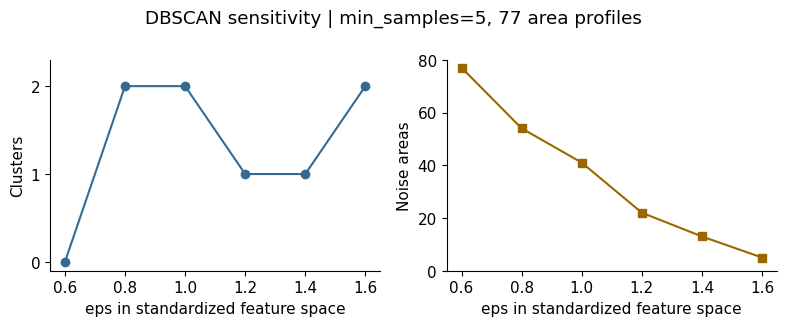

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.3))
axes[0].plot(eps_scores["eps"], eps_scores["Clusters"], "o-", color="#326B93")
axes[1].plot(eps_scores["eps"], eps_scores["Noise areas"], "s-", color="#9A6700")
axes[0].set(xlabel="eps in standardized feature space", ylabel="Clusters",
            yticks=[0, 1, 2], ylim=(-0.1, 2.3))
axes[1].set(xlabel="eps in standardized feature space", ylabel="Noise areas",
            ylim=(0, 80))
fig.suptitle("DBSCAN sensitivity | min_samples=5, 77 area profiles")
fig.tight_layout()
plt.show()

<div dir="rtl" align="right">

## گام ۵ مقایسه و خروجی قابل بررسی
همه برچسب‌ها را کنار شناسه منطقه و سهم‌های واقعی ذخیره می‌کنیم. برای نمایش دوبعدی، PCA را فقط پس از خوشه‌بندی به کار می‌بریم؛ الگوریتم‌ها روی پنج ویژگی استانداردشده اجرا شده‌اند، نه روی دو محور شکل. رنگ‌ها در هر پنل مستقل‌اند و شماره یکسان خوشه به معنی اعضای یکسان نیست.

</div>

In [15]:
assignments = profiles.copy()
assignments.insert(0, "Recorded incidents", records_per_area)
assignments["KMeans"] = k_labels
assignments["Ward"] = h_labels
assignments["DBSCAN"] = db_labels
assignments["DBSCAN role"] = roles
display(assignments[["Recorded incidents", "KMeans", "Ward", "DBSCAN"]].head(5))

Primary Type,Recorded incidents,KMeans,Ward,DBSCAN
Community Area,,,,
1,3277,2,0,0
2,2915,2,0,0
3,3071,2,0,-1
4,1631,2,0,-1
5,974,1,0,-1


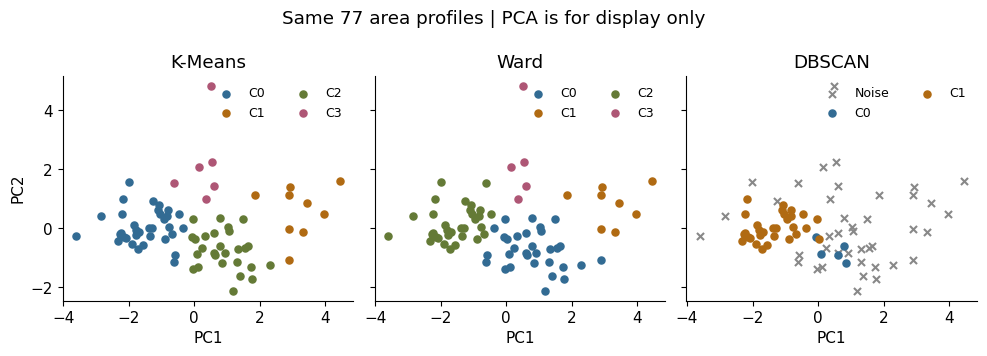

PCA display variance: 0.816


In [16]:
from sklearn.decomposition import PCA

projection = PCA(n_components=2, svd_solver="full")
P = projection.fit_transform(X)
colors = ["#326B93", "#B06A12", "#647A36", "#AE5675"]
fig, axes = plt.subplots(1, 3, figsize=(10, 3.6), sharex=True, sharey=True)
for ax, labels, title in zip(axes, [k_labels, h_labels, db_labels],
                            ["K-Means", "Ward", "DBSCAN"]):
    for label in sorted(set(labels)):
        selected = labels == label
        ax.scatter(P[selected, 0], P[selected, 1], s=26,
                   marker="x" if label == -1 else "o",
                   color="#888888" if label == -1 else colors[label % 4],
                   label="Noise" if label == -1 else f"C{label}")
    ax.set(title=title, xlabel="PC1")
    ax.legend(frameon=False, fontsize=9, ncol=2, loc="upper right")
axes[0].set_ylabel("PC2")
fig.suptitle("Same 77 area profiles | PCA is for display only")
fig.tight_layout()
plt.show()
print("PCA display variance:", round(projection.explained_variance_ratio_.sum(), 3))

<div dir="rtl" align="right">

نمودار دوبعدیِ PCA، همهٔ فاصله‌های فضای پنج‌بعدی را حفظ نمی‌کند؛ نزدیکی یا هم‌پوشانی در تصویر باید با این محدودیت خوانده شود. در محاسبهٔ سیلوئت DBSCAN، ردیف‌های نویز کنار گذاشته می‌شوند؛ بنابراین آن امتیاز روی مجموعهٔ کوچک‌تری محاسبه شده و به‌تنهایی برای رتبه‌بندی روش‌ها کافی نیست.

</div>

In [17]:
evaluation_rows = []
for name, labels in [("KMeans", k_labels), ("Ward", h_labels),
                     ("DBSCAN", db_labels)]:
    kept = labels != -1
    clusters = len(np.unique(labels[kept]))
    valid = 2 <= clusters < int(kept.sum())
    score = silhouette_score(X[kept], labels[kept]) if valid else np.nan
    evaluation_rows.append({"Method": name, "Clusters": clusters,
        "Evaluated areas": int(kept.sum()), "Noise areas": int((~kept).sum()),
        "Silhouette without noise": score})
evaluation = pd.DataFrame(evaluation_rows).set_index("Method")
display(evaluation.round(4))

,Clusters,Evaluated areas,Noise areas,Silhouette without noise
Method,,,,
KMeans,4,77,0,0.3492
Ward,4,77,0,0.3461
DBSCAN,2,36,41,0.3962


<div dir="rtl" align="right">

### تکمیل کوتاه با HDBSCAN
HDBSCAN در معرفی فصل نام برده شده است؛ برای دیدن تفاوت آن با DBSCAN، یک اجرای کوتاه با حداقل اندازه خوشه ۵ و min_samples برابر ۵ داریم. انتخاب تنظیمات، آموزشی است. اگر داده با این تنظیمات خوشه متراکم کافی نداشته باشد، سهم نویز بالا می‌رود؛ الگوریتم مجبور نیست همه مناطق را گروه‌بندی کند.

</div>

In [18]:
from sklearn.cluster import HDBSCAN

hdbscan = HDBSCAN(min_cluster_size=5, min_samples=5, copy=True).fit(X)
assignments["HDBSCAN"] = hdbscan.labels_
display(pd.Series(hdbscan.labels_).value_counts().sort_index().rename("Areas").to_frame())

,Areas
-1,61
0,5
1,11


<div dir="rtl" align="right">

در این اجرا دو خوشه با ۵ و ۱۱ عضو و ۶۱ منطقه نویز داریم. با این پوشش کم، نتیجه را جایگزین برتر K-Means یا Ward معرفی نمی‌کنیم. در HDBSCAN نیز برچسب ۱−، خطا یا خطر را اثبات نمی‌کند.

**حاصل فصل:** یک ورودی مشترک، چند تعریف متفاوت از شباهت و خوشه، و خروجی‌هایی قابل بازرسی داریم. برای تصمیم تحلیلی باید ویژگی‌ها، تعداد اعضا، حساسیت به تنظیمات و معنای مسئله را با هم بررسی کنیم. هیچ شاخص داخلی به‌تنهایی صحت کاربرد عملیاتی را اثبات نمی‌کند.

</div>

In [19]:
import sklearn, scipy

assert len(profiles) == 77 and profiles.shape[1] == 5
assert profiles.index.is_unique and np.isfinite(X).all()
assert records_per_area.sum() == len(work)
assert assignments.index.equals(profiles.index)
assert len(k_labels) == len(h_labels) == len(db_labels) == len(profiles)
output = Path("outputs16")
output.mkdir(exist_ok=True)
assignments.to_csv(output / "Area_profiles_and_clusters.csv", encoding="utf-8-sig")
pd.DataFrame(X, index=profiles.index, columns=features).to_csv(
    output / "Standardized_profiles.csv", encoding="utf-8-sig")
k_scores.to_csv(output / "K_selection.csv")
cluster_means.to_csv(output / "KMeans_cluster_profiles.csv")
linkage_scores.to_csv(output / "Linkage_comparison.csv")
eps_scores.to_csv(output / "DBSCAN_sensitivity.csv", index=False)
evaluation.to_csv(output / "Clustering_evaluation.csv")
np.save(output / "Ward_linkage.npy", Z)
print("Checks passed. Saved outputs to:", output)
print("Versions:", pd.__version__, np.__version__, sklearn.__version__, scipy.__version__)

Checks passed. Saved outputs to: outputs16
Versions: 2.3.3 2.3.5 1.7.2 1.15.3


<div dir="rtl" align="right">

## منابع و محدوده اجرا
مراجع روش‌ها:
- K-Means و معیارهای داخلی: https://scikit-learn.org/stable/modules/clustering.html
- Silhouette: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html
- Ward و انواع پیوند: https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html
- DBSCAN: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html
- HDBSCAN: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.HDBSCAN.html

روش‌های تشخیص ناهنجاری و قواعد وابستگی در ابتدای فصل فقط معرفی شده‌اند؛ موضوع کدهای این فصل خوشه‌بندی است. برای تحلیل سال دیگر، پوشش داده را دوباره بررسی کنید و اعداد متن را از اجرای جدید بگیرید.

</div>